In [4]:
# Data Handling
import pandas as pd
import numpy as np
import math

# Remove truncation of columns and rows in output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy.stats import zscore

In [5]:
# Load the dataset
df = pd.read_csv('../data/raw/cc_underwriting_100k.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (100000, 200)


,applicant_id,age,gender,generation,marital_status,dependents_count,education_level,employment_status,occupation_category,industry_sector,years_employed,state,zip_code_prefix,housing_status,years_at_current_address,us_citizen_status,military_status,annual_income,monthly_income,other_annual_income,total_household_income,monthly_rent_mortgage,monthly_car_payment,monthly_utilities,monthly_insurance,monthly_food_expense,monthly_entertainment_expense,monthly_subscriptions,total_monthly_expenses,savings_account_balance,checking_account_balance,investment_portfolio_balance,retirement_account_balance,total_assets,total_liabilities,net_worth,debt_to_income_ratio,fico_score,equifax_score,experian_score,transunion_score,avg_bureau_score,credit_history_length_months,num_total_credit_accounts,num_open_accounts,num_closed_accounts,num_credit_cards,num_retail_store_cards,num_auto_loans,num_mortgage_accounts,num_student_loans,num_personal_loans,total_revolving_credit_limit,total_revolving_balance_used,credit_utilization_ratio,hard_inquiries_last_6mo,hard_inquiries_last_12mo,hard_inquiries_last_24mo,late_payments_last_12mo,late_payments_last_24mo,derogatory_marks_count,collections_accounts,bankruptcy_count,foreclosure_count,repossession_count,oldest_account_age_months,newest_account_age_months,has_bank_account,bank_relationship_years,checking_account_age_months,savings_account_age_months,avg_monthly_deposits,avg_monthly_withdrawals,nsf_incidents_last_12mo,overdraft_incidents_last_12mo,direct_deposit_flag,payroll_direct_deposit_amount,has_existing_credit_card,existing_cc_balance,existing_cc_credit_limit,has_existing_mortgage,has_existing_auto_loan,application_channel,application_date,application_year,application_month,application_quarter,application_hour,application_day_of_week,requested_credit_limit,card_type_requested,annual_fee_preference,reward_type_preference,promotional_offer_flag,co_applicant_flag,authorized_user_count,promo_code_used,fraud_risk_score,identity_verification_score,address_stability_score,employment_verification_status,income_verification_status,stated_vs_verified_income_ratio,prior_default_flag,prior_bankruptcy_flag,high_risk_industry_flag,recent_address_change_flag,recent_employment_change_flag,multiple_applications_flag,application_velocity_score,synthetic_identity_score,thin_file_flag,no_hit_flag,predicted_default_probability,loss_given_default_estimate,revolving_balance,revolving_credit_limit,revolving_utilization_rate,total_installment_balance,monthly_installment_payment,open_revolving_accounts,open_installment_accounts,mortgage_outstanding_balance,auto_loan_outstanding_balance,student_loan_outstanding_balance,personal_loan_outstanding_balance,max_delinquency_days_ever,max_delinquency_days_24mo,months_since_last_delinquency,months_since_last_inquiry,months_since_last_derogatory,public_records_count,tax_liens_count,civil_judgments_count,child_support_obligation,estimated_spend_segment,travel_frequency,online_shopping_frequency,active_subscription_count,monthly_restaurant_spend,monthly_gas_spend,monthly_grocery_spend,monthly_healthcare_spend,monthly_entertainment_spend,monthly_home_improvement_spend,estimated_annual_card_spend,preferred_payment_method,digital_wallet_user,autopay_setup_likelihood,paperless_statements_preference,fed_funds_rate_at_application,state_unemployment_rate,state_median_household_income,cost_of_living_index,housing_price_index,cpi_inflation_rate,economic_cycle_phase,regional_credit_stress_index,income_to_requested_limit_ratio,fico_score_tier,age_group,employment_stability_score,payment_behavior_score,credit_utilization_tier,inquiry_burden_score,account_type_mix_score,derogatory_severity_score,income_stability_score,bureau_score_variance,affordability_index,credit_capacity_ratio,monthly_disposable_income,disposable_income_ratio,financial_health_score,underwriting_model_score_v1,underwriting_model_score_v2,underwriting_model_score_v3,combined_risk_score,target_approved,target_credit_limit_assigned,p

# What is the Business Problem?

**Decide wether to approve or decline credit card application for a given applicant**
- What is our target variable? => `target approval`

**Constraints** : Fair Lending: Demographic variables (gender, age, race proxies) are included for fairness auditing only. They must not be used as direct underwriting inputs in compliance with ECOA and the Fair Housing Act. 

## 1. Dataset Overview

This synthetic dataset simulates a US consumer banking credit card underwriting pipeline. It covers the full applicant journey — from demographic capture and credit bureau pull through behavioral signals and economic context — to a final credit decision.
The dataset is designed for machine learning model development, fair lending analytics, explainability research, and AI platform prototyping in the BFSI domain.

All data is synthetically generated using statistically realistic distributions calibrated to US consumer credit norms. No real applicant data is included. The dataset is fully reproducible (NumPy random seed = 42).


## 2. Data Types and Basic Info

In [6]:
# ── Quick EDA snapshot ──
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNumeric columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")
print(f"\nDate columns: {df.select_dtypes(include=['datetime']).columns.tolist()}")
print(f"\nDescriptive statistics:")
df.describe().round(2)

DATASET SUMMARY

Shape: 100,000 rows × 200 columns

Numeric columns: ['age', 'dependents_count', 'years_employed', 'zip_code_prefix', 'years_at_current_address', 'annual_income', 'monthly_income', 'other_annual_income', 'total_household_income', 'monthly_rent_mortgage', 'monthly_car_payment', 'monthly_utilities', 'monthly_insurance', 'monthly_food_expense', 'monthly_entertainment_expense', 'monthly_subscriptions', 'total_monthly_expenses', 'savings_account_balance', 'checking_account_balance', 'investment_portfolio_balance', 'retirement_account_balance', 'total_assets', 'total_liabilities', 'net_worth', 'debt_to_income_ratio', 'fico_score', 'equifax_score', 'experian_score', 'transunion_score', 'avg_bureau_score', 'credit_history_length_months', 'num_total_credit_accounts', 'num_open_accounts', 'num_closed_accounts', 'num_credit_cards', 'num_retail_store_cards', 'num_auto_loans', 'num_mortgage_accounts', 'num_student_loans', 'num_personal_loans', 'total_revolving_credit_limit', 'total_

/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_55923/3531689873.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"\nCategorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")


,age,dependents_count,years_employed,zip_code_prefix,years_at_current_address,annual_income,monthly_income,other_annual_income,total_household_income,monthly_rent_mortgage,monthly_car_payment,monthly_utilities,monthly_insurance,monthly_food_expense,monthly_entertainment_expense,monthly_subscriptions,total_monthly_expenses,savings_account_balance,checking_account_balance,investment_portfolio_balance,retirement_account_balance,total_assets,total_liabilities,net_worth,debt_to_income_ratio,fico_score,equifax_score,experian_score,transunion_score,avg_bureau_score,credit_history_length_months,num_total_credit_accounts,num_open_accounts,num_closed_accounts,num_credit_cards,num_retail_store_cards,num_auto_loans,num_mortgage_accounts,num_student_loans,num_personal_loans,total_revolving_credit_limit,total_revolving_balance_used,credit_utilization_ratio,hard_inquiries_last_6mo,hard_inquiries_last_12mo,hard_inquiries_last_24mo,late_payments_last_12mo,late_payments_last_24mo,derogatory_marks_count,collections_accounts,bankruptcy_count,foreclosure_count,repossession_count,oldest_account_age_months,newest_account_age_months,bank_relationship_years,checking_account_age_months,savings_account_age_months,avg_monthly_deposits,avg_monthly_withdrawals,nsf_incidents_last_12mo,overdraft_incidents_last_12mo,payroll_direct_deposit_amount,existing_cc_balance,existing_cc_credit_limit,application_year,application_month,application_hour,requested_credit_limit,authorized_user_count,fraud_risk_score,identity_verification_score,address_stability_score,stated_vs_verified_income_ratio,application_velocity_score,synthetic_identity_score,predicted_default_probability,loss_given_default_estimate,revolving_balance,revolving_credit_limit,revolving_utilization_rate,total_installment_balance,monthly_installment_payment,open_revolving_accounts,open_installment_accounts,mortgage_outstanding_balance,auto_loan_outstanding_balance,student_loan_outstanding_balance,personal_loan_outstanding_balance,max_delinquency_days_ever,max_delinquency_days_24mo,months_since_last_delinquency,months_since_last_inquiry,months_since_last_derogatory,public_records_count,tax_liens_count,civil_judgments_count,active_subscription_count,monthly_restaurant_spend,monthly_gas_spend,monthly_grocery_spend,monthly_healthcare_spend,monthly_entertainment_spend,monthly_home_improvement_spend,estimated_annual_card_spend,autopay_setup_likelihood,fed_funds_rate_at_application,state_unemployment_rate,state_median_household_income,cost_of_living_index,housing_price_index,cpi_inflation_rate,regional_credit_stress_index,income_to_requested_limit_ratio,employment_stability_score,payment_behavior_score,inquiry_burden_score,account_type_mix_score,derogatory_severity_score,income_stability_score,bureau_score_variance,affordability_index,credit_capacity_ratio,monthly_disposable_income,disposable_income_ratio,financial_health_score,underwriting_model_score_v1,underwriting_model_score_v2,underwriting_model_score_v3,combined_risk_score,target_credit_limit_assigned,banking_product_count,avg_transaction_amount,num_transactions_last_30d,largest_single_purchase_ever,months_since_last_cc_application,self_reported_monthly_rent,application_completion_time_mins,income_growth_rate_yoy,num_address_changes_5yr
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000

## Dataset Column Descriptions

| Column | Description |
|--------|-------------|
| `applicant_id` | Unique identifier for each credit card applicant |
| `age` | Applicant's age in years |
| `gender` | Applicant's gender |
| `generation` | Generational cohort (e.g., Gen X, Millennial, Boomer) |
| `marital_status` | Marital status (Single, Married, Divorced, etc.) |
| `dependents_count` | Number of financial dependents |
| `education_level` | Highest level of education attained |
| `employment_status` | Employment type (Full-Time, Part-Time, Self-Employed, Unemployed, etc.) |
| `occupation_category` | Broad category of the applicant's occupation |
| `industry_sector` | Industry sector of current employer |
| `years_employed` | Years at current employer |
| `state` | US state of residence |
| `zip_code_prefix` | First 5 digits of applicant's zip code |
| `housing_status` | Housing situation (Own, Rent, Mortgage, etc.) |
| `years_at_current_address` | Years at current address |
| `us_citizen_status` | Whether the applicant is a US citizen |
| `military_status` | Military service status |
| `annual_income` | Stated annual income (USD) |
| `monthly_income` | Monthly income derived from annual income |
| `other_annual_income` | Other sources of annual income (USD) |
| `total_household_income` | Combined household annual income (USD) |
| `monthly_rent_mortgage` | Monthly housing payment (rent or mortgage) |
| `monthly_car_payment` | Monthly car loan or lease payment |
| `monthly_utilities` | Monthly utilities expense |
| `monthly_insurance` | Monthly insurance premiums |
| `monthly_food_expense` | Monthly food/grocery expense |
| `monthly_entertainment_expense` | Monthly entertainment spending |
| `monthly_subscriptions` | Monthly subscription services cost |
| `total_monthly_expenses` | Sum of all monthly expense categories |
| `savings_account_balance` | Current savings account balance (USD) |
| `checking_account_balance` | Current checking account balance (USD) |
| `investment_portfolio_balance` | Total value of investment accounts (USD) |
| `retirement_account_balance` | Total value of retirement accounts (USD) |
| `total_assets` | Sum of all reported assets (USD) |
| `total_liabilities` | Sum of all reported liabilities (USD) |
| `net_worth` | Total assets minus total liabilities (USD) |
| `debt_to_income_ratio` | Total monthly debt payments divided by monthly income |
| `fico_score` | FICO credit score |
| `equifax_score` | Equifax bureau credit score |
| `experian_score` | Experian bureau credit score |
| `transunion_score` | TransUnion bureau credit score |
| `avg_bureau_score` | Average of the three bureau scores |
| `credit_history_length_months` | Length of credit history in months |
| `num_total_credit_accounts` | Total number of credit accounts ever opened |
| `num_open_accounts` | Number of currently open credit accounts |
| `num_closed_accounts` | Number of closed credit accounts |
| `num_credit_cards` | Number of credit card accounts |
| `num_retail_store_cards` | Number of retail/store credit card accounts |
| `num_auto_loans` | Number of auto loan accounts |
| `num_mortgage_accounts` | Number of mortgage accounts |
| `num_student_loans` | Number of student loan accounts |
| `num_personal_loans` | Number of personal loan accounts |
| `total_revolving_credit_limit` | Total revolving credit limit across all cards (USD) |
| `total_revolving_balance_used` | Total revolving balance currently used (USD) |
| `credit_utilization_ratio` | Revolving balance used divided by total revolving limit |
| `hard_inquiries_last_6mo` | Number of hard credit inquiries in the last 6 months |
| `hard_inquiries_last_12mo` | Number of hard credit inquiries in the last 12 months |
| `hard_inquiries_last_24mo` | Number of hard credit inquiries in the last 24 months |
| `late_payments_last_12mo` | Number of late payments reported in the last 12 months |
| `late_payments_last_24mo` | Number of late payments reported in the last 24 months |
| `derogatory_marks_count` | Total number of derogatory marks on credit report |
| `collections_accounts` | Number of accounts in collections |
| `bankruptcy_count` | Number of bankruptcies filed |
| `foreclosure_count` | Number of foreclosures |
| `repossession_count` | Number of vehicle or asset repossessions |
| `oldest_account_age_months` | Age of oldest credit account in months |
| `newest_account_age_months` | Age of newest credit account in months |
| `has_bank_account` | Whether the applicant has a bank account (Yes/No) |
| `bank_relationship_years` | Years the applicant has had a banking relationship |
| `checking_account_age_months` | Age of checking account in months |
| `savings_account_age_months` | Age of savings account in months |
| `avg_monthly_deposits` | Average monthly deposit amount (USD) |
| `avg_monthly_withdrawals` | Average monthly withdrawal amount (USD) |
| `nsf_incidents_last_12mo` | Non-sufficient funds incidents in the last 12 months |
| `overdraft_incidents_last_12mo` | Overdraft incidents in the last 12 months |
| `direct_deposit_flag` | Whether applicant has direct deposit set up (Yes/No) |
| `payroll_direct_deposit_amount` | Regular payroll direct deposit amount (USD) |
| `has_existing_credit_card` | Whether applicant currently holds a credit card (Yes/No) |
| `existing_cc_balance` | Current balance on existing credit cards (USD) |
| `existing_cc_credit_limit` | Credit limit on existing credit cards (USD) |
| `has_existing_mortgage` | Whether applicant has an active mortgage (Yes/No) |
| `has_existing_auto_loan` | Whether applicant has an active auto loan (Yes/No) |
| `application_channel` | Channel through which application was submitted (Online, Branch, Mail, etc.) |
| `application_date` | Date the application was submitted |
| `application_year` | Year of application |
| `application_month` | Month of application |
| `application_quarter` | Quarter of application (Q1–Q4) |
| `application_hour` | Hour of day the application was submitted |
| `application_day_of_week` | Day of the week the application was submitted |
| `requested_credit_limit` | Credit limit requested by the applicant (USD) |
| `card_type_requested` | Type of card requested (Classic, Gold, Platinum, Business, etc.) |
| `annual_fee_preference` | Preferred annual fee tier (No Annual Fee, Low, Medium, High) |
| `reward_type_preference` | Preferred rewards type (Cash Back, Travel Points, etc.) |
| `promotional_offer_flag` | Whether applicant was responding to a promotional offer (Yes/No) |
| `co_applicant_flag` | Whether a co-applicant is included (Yes/No) |
| `authorized_user_count` | Number of authorized users requested on the account |
| `promo_code_used` | Promotional code used during application, if any |
| `fraud_risk_score` | Model-generated fraud risk score (0–1, higher = riskier) |
| `identity_verification_score` | Identity verification confidence score (0–1) |
| `address_stability_score` | Score reflecting stability of applicant's address history (0–1) |
| `employment_verification_status` | Result of employment verification (Verified, Unverifiable, Pending) |
| `income_verification_status` | Result of income verification (Verified, Stated, Pending) |
| `stated_vs_verified_income_ratio` | Ratio of stated income to verified income |
| `prior_default_flag` | Whether applicant has prior defaults on record (Yes/No) |
| `prior_bankruptcy_flag` | Whether applicant has a prior bankruptcy (Yes/No) |
| `high_risk_industry_flag` | Whether applicant works in a high-risk industry (Yes/No) |
| `recent_address_change_flag` | Whether applicant recently changed address (Yes/No) |
| `recent_employment_change_flag` | Whether applicant recently changed employer (Yes/No) |
| `multiple_applications_flag` | Whether multiple credit applications were submitted recently (Yes/No) |
| `application_velocity_score` | Score measuring frequency of recent credit applications |
| `synthetic_identity_score` | Risk score for potential synthetic identity fraud (0–1) |
| `thin_file_flag` | Whether applicant has a thin credit file (Yes/No) |
| `no_hit_flag` | Whether applicant returned no credit bureau hit (Yes/No) |
| `predicted_default_probability` | Model-predicted probability of default (0–1) |
| `loss_given_default_estimate` | Estimated loss amount if applicant defaults (USD) |
| `revolving_balance` | Total current revolving balance (USD) |
| `revolving_credit_limit` | Total revolving credit limit available (USD) |
| `revolving_utilization_rate` | Revolving balance as a fraction of revolving limit |
| `total_installment_balance` | Total outstanding balance across installment loans (USD) |
| `monthly_installment_payment` | Total required monthly installment payments (USD) |
| `open_revolving_accounts` | Number of open revolving credit accounts |
| `open_installment_accounts` | Number of open installment loan accounts |
| `mortgage_outstanding_balance` | Outstanding mortgage balance (USD) |
| `auto_loan_outstanding_balance` | Outstanding auto loan balance (USD) |
| `student_loan_outstanding_balance` | Outstanding student loan balance (USD) |
| `personal_loan_outstanding_balance` | Outstanding personal loan balance (USD) |
| `max_delinquency_days_ever` | Maximum days past due ever recorded on any account |
| `max_delinquency_days_24mo` | Maximum days past due in the last 24 months |
| `months_since_last_delinquency` | Months since the most recent delinquency (999 = never) |
| `months_since_last_inquiry` | Months since the most recent hard inquiry (999 = never) |
| `months_since_last_derogatory` | Months since the most recent derogatory event (999 = never) |
| `public_records_count` | Number of public record items (bankruptcies, liens, judgments) |
| `tax_liens_count` | Number of tax liens on record |
| `civil_judgments_count` | Number of civil judgments on record |
| `child_support_obligation` | Whether applicant has a child support obligation (Yes/No) |
| `estimated_spend_segment` | Estimated spending tier (e.g., Moderate, Premium, Super Prime) |
| `travel_frequency` | How frequently the applicant travels (Never, Rarely, Monthly, etc.) |
| `online_shopping_frequency` | Frequency of online shopping activity |
| `active_subscription_count` | Number of active paid subscriptions |
| `monthly_restaurant_spend` | Estimated monthly restaurant/dining spend (USD) |
| `monthly_gas_spend` | Estimated monthly gas/fuel spend (USD) |
| `monthly_grocery_spend` | Estimated monthly grocery spend (USD) |
| `monthly_healthcare_spend` | Estimated monthly healthcare spend (USD) |
| `monthly_entertainment_spend` | Estimated monthly entertainment spend (USD) |
| `monthly_home_improvement_spend` | Estimated monthly home improvement spend (USD) |
| `estimated_annual_card_spend` | Estimated total annual credit card spend (USD) |
| `preferred_payment_method` | Applicant's preferred payment method (Debit Card, Digital Wallet, etc.) |
| `digital_wallet_user` | Whether applicant uses a digital wallet (Yes/No) |
| `autopay_setup_likelihood` | Predicted likelihood of enrolling in autopay (0–1) |
| `paperless_statements_preference` | Whether applicant prefers paperless statements (Yes/No) |
| `fed_funds_rate_at_application` | Federal funds rate at time of application |
| `state_unemployment_rate` | Unemployment rate in applicant's state at time of application |
| `state_median_household_income` | Median household income in applicant's state (USD) |
| `cost_of_living_index` | Cost of living index for applicant's location |
| `housing_price_index` | Housing price index for applicant's region |
| `cpi_inflation_rate` | Consumer Price Index inflation rate at time of application |
| `economic_cycle_phase` | Macroeconomic phase at application time (Expansion, Normalization, Tightening, etc.) |
| `regional_credit_stress_index` | Regional credit stress index score |
| `income_to_requested_limit_ratio` | Annual income divided by requested credit limit |
| `fico_score_tier` | Categorical FICO tier (Very Poor, Fair, Good, Very Good, Exceptional) |
| `age_group` | Applicant's age group bucket (e.g., 25-34, 35-44) |
| `employment_stability_score` | Derived score measuring employment stability (0–1) |
| `payment_behavior_score` | Derived score reflecting on-time payment track record (0–1) |
| `credit_utilization_tier` | Categorical utilization tier (Low, Good, High, Very High) |
| `inquiry_burden_score` | Derived score capturing volume and recency of hard inquiries |
| `account_type_mix_score` | Score reflecting diversity of credit account types (0–1) |
| `derogatory_severity_score` | Weighted severity score based on derogatory events (0–1) |
| `income_stability_score` | Derived score for stability of income sources (0–1) |
| `bureau_score_variance` | Variance across the three bureau scores |
| `affordability_index` | Ratio of disposable income to requested credit limit payments |
| `credit_capacity_ratio` | Available credit relative to total credit limit |
| `monthly_disposable_income` | Monthly income minus total monthly expenses (USD) |
| `disposable_income_ratio` | Disposable income as a fraction of monthly income |
| `financial_health_score` | Composite score reflecting overall financial health (0–1) |
| `underwriting_model_score_v1` | Underwriting risk score from model version 1 |
| `underwriting_model_score_v2` | Underwriting risk score from model version 2 |
| `underwriting_model_score_v3` | Underwriting risk score from model version 3 |
| `combined_risk_score` | Ensemble risk score combining all underwriting model versions |
| `target_approved` | Target variable — whether the application was approved (Yes/No) |
| `target_credit_limit_assigned` | Target variable — credit limit assigned upon approval (USD) |
| `phone_type` | Type of phone contact provided (Mobile, Landline) |
| `email_domain_type` | Email provider type (Gmail, Yahoo, Outlook, Corporate, etc.) |
| `credit_freeze_flag` | Whether applicant has a credit freeze active (Yes/No) |
| `opt_out_prescreened` | Whether applicant has opted out of pre-screened credit offers (Yes/No) |
| `banking_product_count` | Number of banking products held with the institution |
| `mobile_banking_user` | Whether applicant uses mobile banking (Yes/No) |
| `avg_transaction_amount` | Average transaction amount on existing accounts (USD) |
| `num_transactions_last_30d` | Number of transactions in the last 30 days |
| `largest_single_purchase_ever` | Largest single purchase amount ever recorded (USD) |
| `months_since_last_cc_application` | Months since applicant last applied for a credit card |
| `self_reported_monthly_rent` | Monthly rent as self-reported by the applicant (USD) |
| `bureau_pull_consent` | Type of bureau pull consent given (Hard Pull, Soft Pull) |
| `application_completion_time_mins` | Time taken to complete the application in minutes |
| `prior_cc_with_this_bank` | Whether applicant previously held a credit card with this bank (Yes/No) |
| `loyalty_program_member` | Whether applicant is a bank loyalty program member (Yes/No) |
| `credit_counseling_flag` | Whether applicant is or has been enrolled in credit counseling (Yes/No) |
| `income_growth_rate_yoy` | Year-over-year income growth rate |
| `num_address_changes_5yr` | Number of address changes in the last 5 years |
| `stated_purpose` | Stated purpose for the credit card (Travel, Everyday Purchases, etc.) |
| `marketing_segment` | Marketing segment assigned to the applicant (Affluent, Emerging Affluent, etc.) |

## 2. Missing Values

In [7]:
# Count nulls per column and express as a percentage of total rows
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Combine into a single table and show only columns that have at least one missing value
missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
missing_df[missing_df["Missing"] > 0].sort_values("% Missing", ascending=False)

,Missing,% Missing
military_status,87815,87.82
promo_code_used,69972,69.97
phone_type,5030,5.03


- `miltary_status` is missing for 87.82 % of rows. Indicates there is no value being assigned for non-military person. 
- `promo_code_used` is missing for 69.97 % of rows. Indicates most applications don't use a promo code.
- `phone type` column is most likely MCAR and most likely has a low IV. 

## 3. Target Variable - ``target_approved``

<Axes: xlabel='target_approved'>

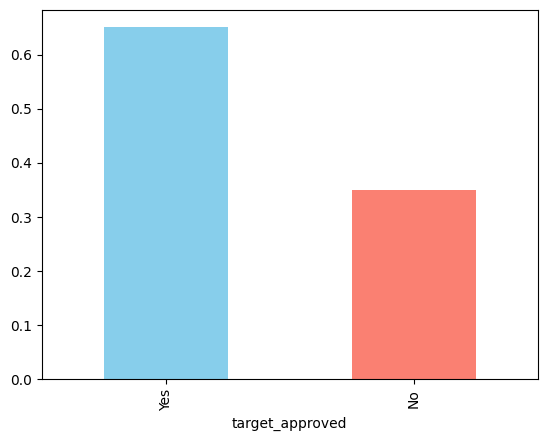

In [8]:
# Print target approval rate. 
df['target_approved'].value_counts(normalize=True).round(4).plot(kind='bar', color=['skyblue', 'salmon'])

Our dataset is somewhat imbalanced but we have plently of non-approved rows to work with to solve the business problem

## 4. Numerical Feature Distribution

In [9]:
# Make sure all numerical columns have numeric data types and change if necessary
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 200 columns):
 #    Column                             Dtype  
---   ------                             -----  
 0    applicant_id                       str    
 1    age                                int64  
 2    gender                             str    
 3    generation                         str    
 4    marital_status                     str    
 5    dependents_count                   int64  
 6    education_level                    str    
 7    employment_status                  str    
 8    occupation_category                str    
 9    industry_sector                    str    
 10   years_employed                     int64  
 11   state                              str    
 12   zip_code_prefix                    int64  
 13   housing_status                     str    
 14   years_at_current_address           float64
 15   us_citizen_status                  str    
 16   military_sta

In [10]:
# Numerical columns list
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df_skew = df[numerical_cols].skew().reset_index()
df_skew.columns = ['column', 'skew']

df_skew['distribution_type'] = df_skew['skew'].apply(
    lambda x: "right-skewed" if x > 0.5 else ("left-skewed" if x < -0.5 else "approximately symmetric")
)
print(df_skew['distribution_type'].value_counts(normalize=True))

distribution_type
right-skewed               0.642857
approximately symmetric    0.314286
left-skewed                0.042857
Name: proportion, dtype: float64


Most of the columns values are either positively skewed or normally distributed.

In [14]:
# Seperate columns by distribution type. IQR is more effective for skewed distributions. Z-score is more effective for approximately symmetric distributions.
skewed_cols = df_skew[df_skew['distribution_type'] != 'approximately symmetric']['column'].tolist()
symmetric_cols = df_skew[df_skew['distribution_type'] == 'approximately symmetric']['column'].tolist()

# Check for outliers and any sentinel values in the numerical columns using IQR
outlier_summary = []

# Iterate through numerical columns
for col in skewed_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers_low = (df[col] < lower).sum()
    n_outliers_high = (df[col] > upper).sum()
    
    outlier_summary.append({
        "column": col,
        "outlier_low_%": n_outliers_low / len(df) * 100,
        "outlier_high_%": n_outliers_high / len(df) * 100,
        "outlier_%": (n_outliers_low + n_outliers_high) / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="outlier_%", ascending=False)
print(outlier_df.columns)


# Merge with skewness info to compare outlier percentage and skewness to determine which columns are problematic
outlier_df = outlier_df.merge(df_skew, on='column', how='left')

# Convert to float
outlier_df['outlier_%'] = pd.to_numeric(outlier_df['outlier_%'], errors='coerce')

# Assign problematic status
def assign_problematic_status(row):
    if row['skew'] > 1 and row['outlier_high_%'] > 5: # Problem if right-skewed and >5% outliers on the high end
        status = '🚨'
    elif row['skew'] < -1 and row['outlier_low_%'] > 5: # Problem if left-skewed and >5% outliers on the low end
        status = '🚨'
    else:
        status = '✅' # Not too problematic

    return status
# Apply the function to create a new column 'problematic'
outlier_df['problematic'] = outlier_df.apply(assign_problematic_status, axis=1)

# Keep only columns with <5% outliers
outlier_df = outlier_df[outlier_df['outlier_%'] > 5]

# Show relevant info
outlier_df[['column', 'outlier_%','skew', 'problematic']]

Index(['column', 'outlier_low_%', 'outlier_high_%', 'outlier_%'], dtype='str')


,column,outlier_%,skew,problematic
0,derogatory_marks_count,21.922,2.598033,🚨
1,months_since_last_derogatory,21.922,-1.358866,🚨
2,cpi_inflation_rate,19.917,0.849255,✅
3,overdraft_incidents_last_12mo,15.026,2.863395,🚨
4,max_delinquency_days_ever,15.012,1.676438,🚨
5,late_payments_last_12mo,15.001,3.134916,🚨
6,collections_accounts,14.976,2.875255,🚨
7,investment_portfolio_balance,14.354,15.389964,🚨
8,retirement_account_balance,12.759,9.303520,🚨
9,net_worth,12.311,2.686948,🚨


/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_55923/2731891776.py:41: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kevin/Programming/credit-card-underwritting/.cc_venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


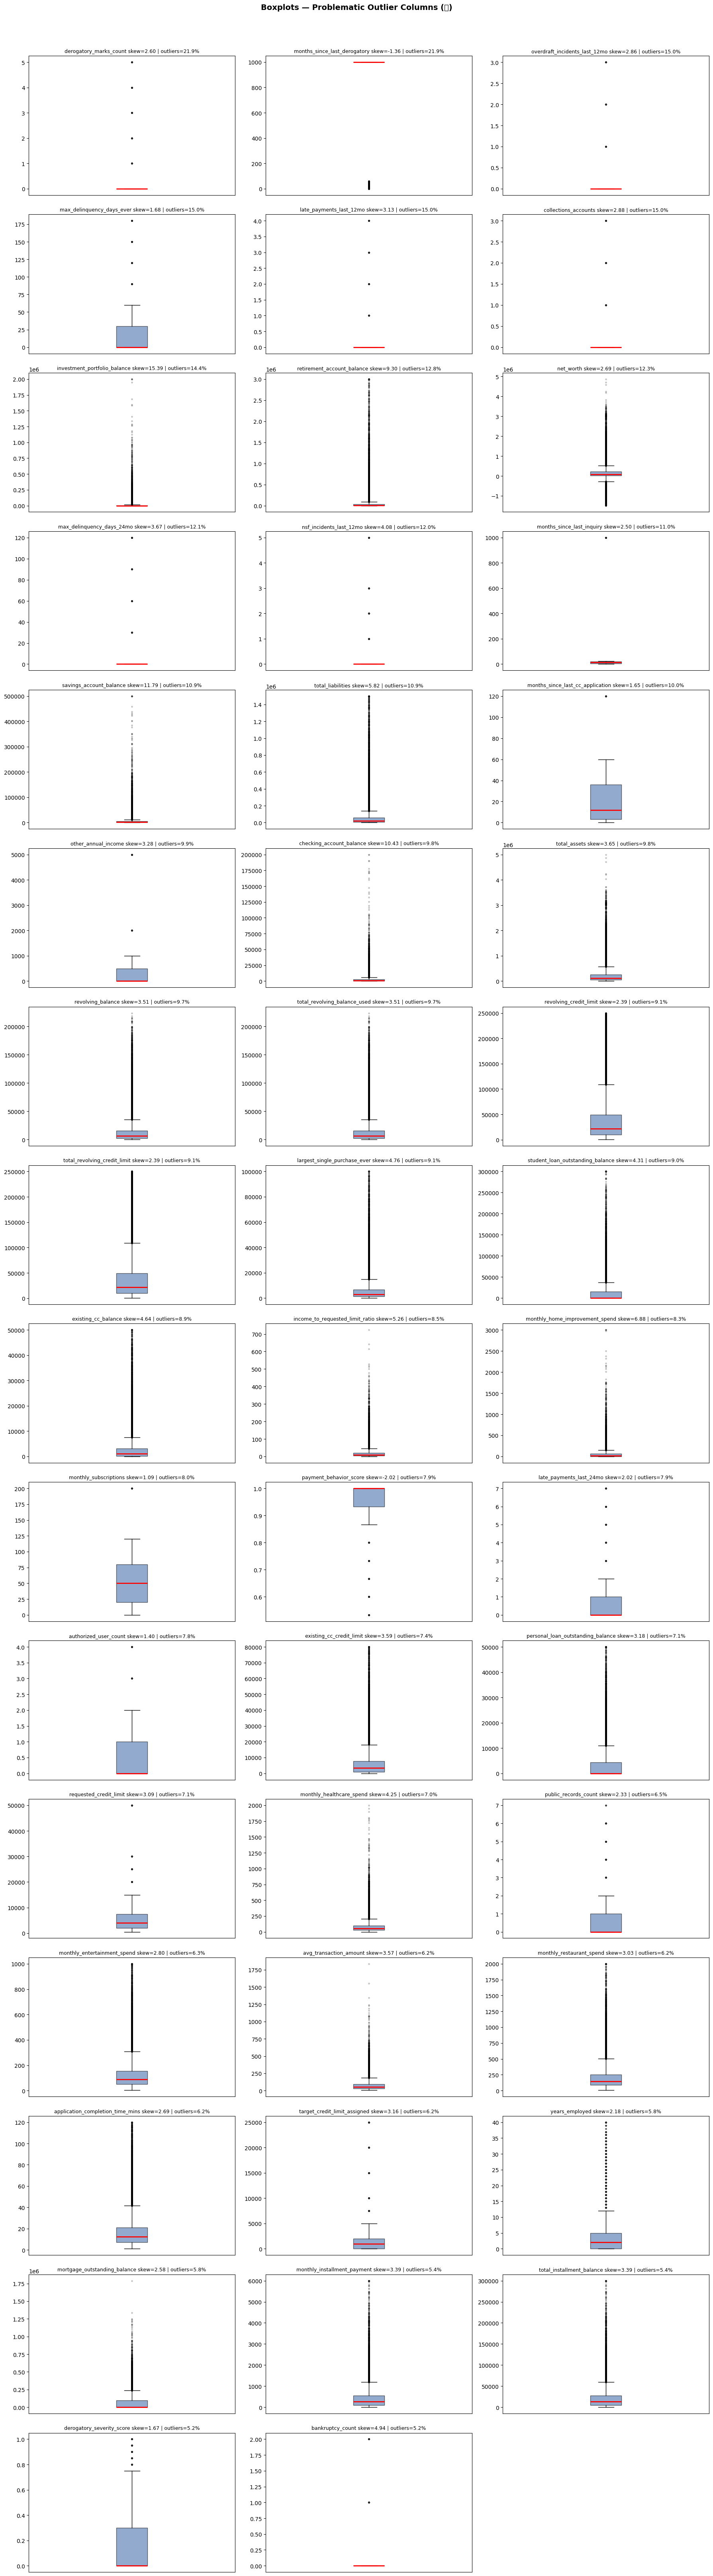

In [15]:
# Filter outlier_df down to only columns flagged as problematic (🚨)
problematic_cols = outlier_df[outlier_df["problematic"] == "🚨"]["column"].tolist()

# Calculate grid dimensions — 3 plots per row
n_cols = 3
n_rows = math.ceil(len(problematic_cols) / n_cols)

# Create the figure and axes grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))

# Flatten axes array so we can iterate over it with a single index
axes = axes.flatten()

for i, col in enumerate(problematic_cols):
    ax = axes[i]

    # Draw the boxplot for the column
    ax.boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#4C72B0", alpha=0.6),
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", markersize=2, alpha=0.3, color="gray"),
    )

    # Pull skew and outlier % from outlier_df for the subtitle
    row_info = outlier_df[outlier_df["column"] == col].iloc[0]
    skew_val = row_info["skew"]
    outlier_pct = row_info["outlier_%"]

    # Title shows column name; subtitle shows skew and outlier % for quick reference
    ax.set_title(f"{col} skew={skew_val:.2f} | outliers={outlier_pct:.1f}%", fontsize=9)
    ax.set_xticks([])

# Hide any unused subplot axes (if total plots < grid cells)
for j in range(len(problematic_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots — Problematic Outlier Columns (🚨)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

`derogatory_marks_count`, `months_since_last_derogatory`, `derogatory_severity_score`, `collections_accounts`, `bankruptcy_count`, `foreclosure_count`, `repossession_count` and a few more columns are all expected despite having significant outliers; most applicants have zero derogatory marks so distribution is expected to be heavilty right skewed. The outliers aren't errors , they're genuin high-risk applicants - which makes these column strong predictors for the target variable.

`months_since_last_delinquency` has a filler values for users that have never missed a value - 999. 

In [18]:
# Z-score is appropriate for symmetric distributions because it assumes normality.
# A z-score measures how many standard deviations a value is from the mean.
# Values beyond ±3 are considered outliers (~0.3% of a normal distribution).
z_threshold = 3

zscore_summary = []

for col in symmetric_cols:
    col_data = df[col].dropna()

    # Compute z-score for each value in the column
    z_scores = zscore(col_data)

    # Flag values whose absolute z-score exceeds the threshold
    n_outliers = (np.abs(z_scores) > z_threshold).sum()

    zscore_summary.append({
        "column": col,
        "n_outliers": n_outliers,
        "outlier_%": n_outliers / len(col_data) * 100,
        "skew": df_skew.loc[df_skew["column"] == col, "skew"].values[0]
    })

zscore_df = (
    pd.DataFrame(zscore_summary)
    .sort_values("outlier_%", ascending=False)
    .reset_index(drop=True)
)

# Flag columns where more than 1% of values are outliers — z-score should rarely exceed
# 0.3% for a truly normal distribution, so anything above 1% warrants attention.
zscore_df["problematic"] = zscore_df["outlier_%"].apply(lambda x: "🚨" if x > 1 else "✅")

zscore_df[['column','outlier_%','problematic']]

,column,outlier_%,problematic
0,experian_score,0.466,✅
1,equifax_score,0.446,✅
2,transunion_score,0.438,✅
3,num_transactions_last_30d,0.368,✅
4,num_total_credit_accounts,0.357,✅
5,income_growth_rate_yoy,0.281,✅
6,stated_vs_verified_income_ratio,0.257,✅
7,housing_price_index,0.249,✅
8,credit_history_length_months,0.189,✅
9,oldest_account_age_months,0.189,✅


## 5. Approval Rate by Key Categorical Features

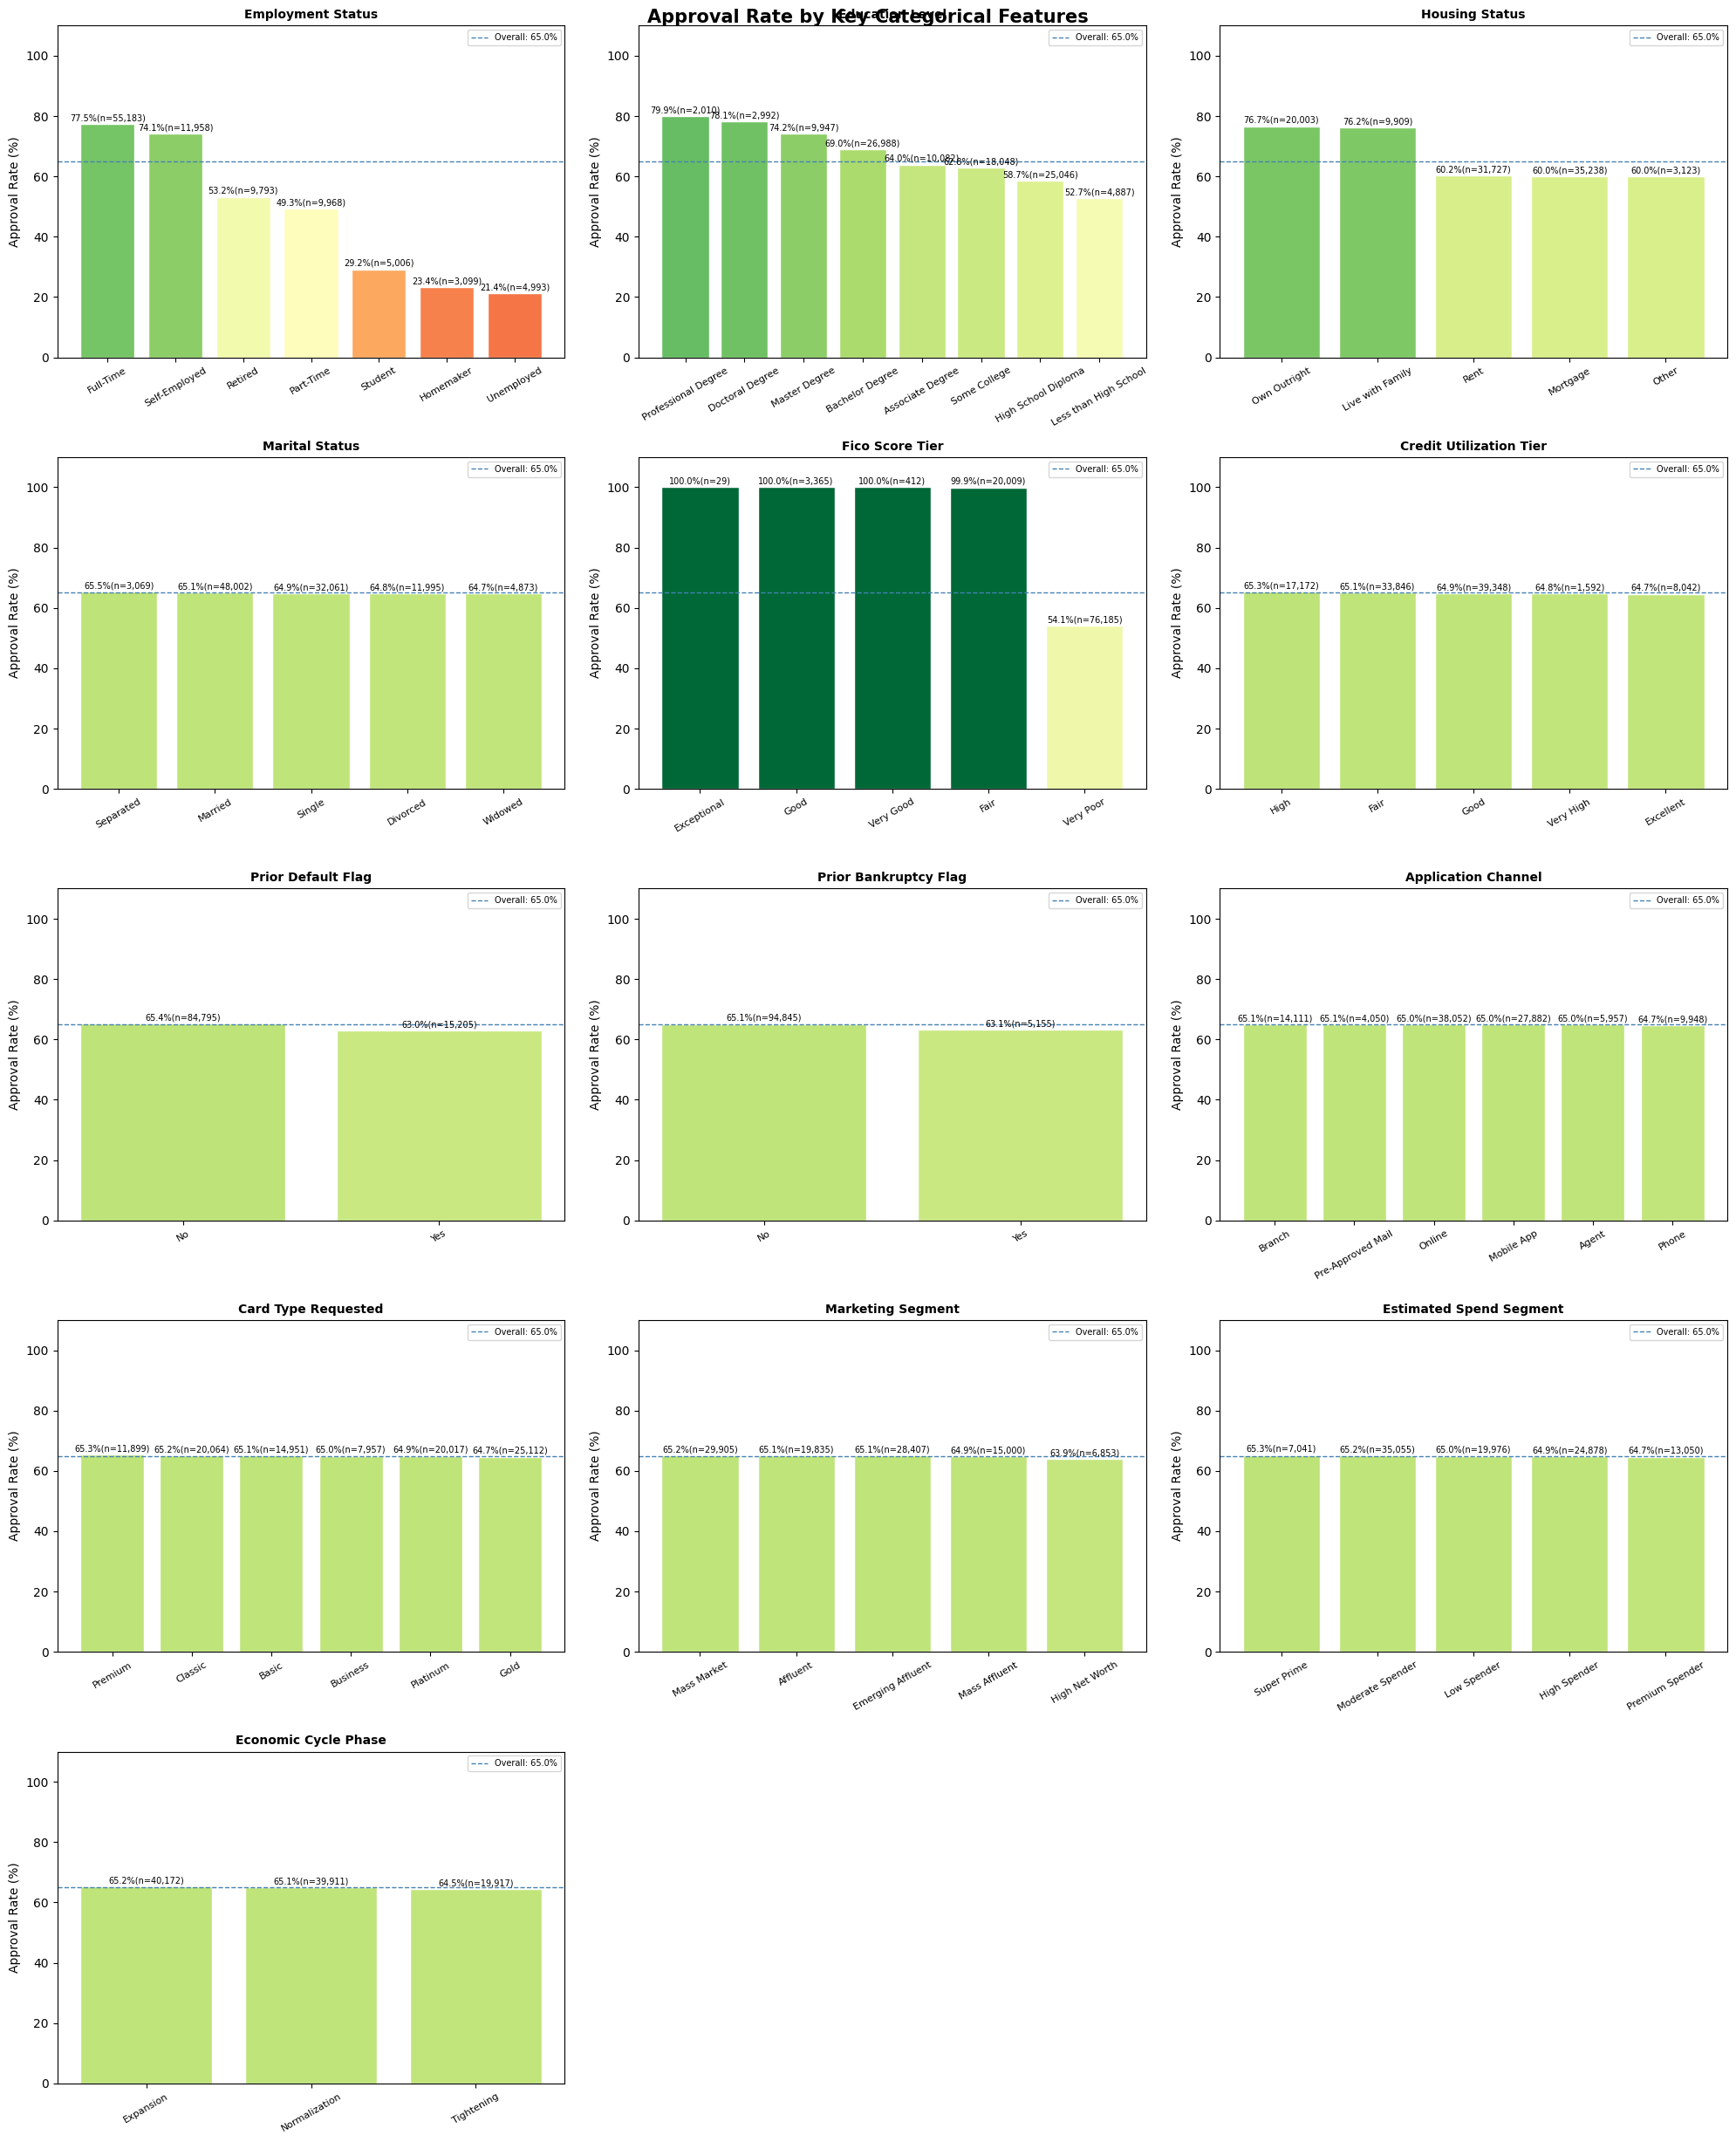

In [21]:
# Key categorical features selected based on underwriting relevance:
# demographics, credit profile tiers, employment, housing, and application context
key_cat_cols = [
    "employment_status", "education_level", "housing_status", "marital_status",
    "fico_score_tier", "credit_utilization_tier",
    "prior_default_flag", "prior_bankruptcy_flag", "application_channel",
    "card_type_requested", "marketing_segment", "estimated_spend_segment",
    "economic_cycle_phase"
]

# Convert target to binary so we can compute a mean approval rate per group
df["approved_binary"] = (df["target_approved"] == "Yes").astype(int)

# Layout: 3 charts per row
n_cols = 3
n_rows = math.ceil(len(key_cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(key_cat_cols):
    ax = axes[i]

    # Compute approval rate and group size per category
    group = (
        df.groupby(col)["approved_binary"]
        .agg(approval_rate="mean", count="count")
        .reset_index()
        .sort_values("approval_rate", ascending=False)
    )

    # Color bars by approval rate — green for high, red for low
    colors = plt.cm.RdYlGn(group["approval_rate"].values)

    bars = ax.bar(group[col].astype(str), group["approval_rate"] * 100, color=colors, edgecolor="white")

    # Annotate each bar with its approval rate % and sample size
    for bar, (_, row) in zip(bars, group.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{row['approval_rate'] * 100:.1f}%(n={row['count']:,})",
            ha="center", va="bottom", fontsize=7
        )

    # Draw a dashed line at the overall approval rate as a baseline reference
    overall_rate = df["approved_binary"].mean() * 100
    ax.axhline(overall_rate, color="steelblue", linestyle="--", linewidth=1, label=f"Overall: {overall_rate:.1f}%")

    ax.set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_ylabel("Approval Rate (%)")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=7)

# Hide unused axes
for j in range(len(key_cat_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Approval Rate by Key Categorical Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

`fico_score_tier` has 100% approval rates in all tiers except "very low". However the approval for the tier is still substancial.

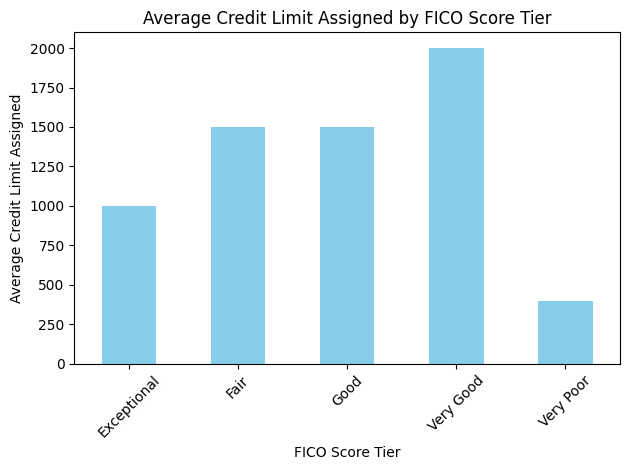

In [26]:
# Analyze average credit limit assigned by FICO score tier to see if it aligns with expected underwriting patterns (higher FICO should generally correspond to higher credit limits).
df.groupby('fico_score_tier')['target_credit_limit_assigned'].median().plot(kind='bar', color='skyblue')
plt.title('Average Credit Limit Assigned by FICO Score Tier')
plt.xlabel('FICO Score Tier')
plt.ylabel('Average Credit Limit Assigned')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Approval Rate per Year

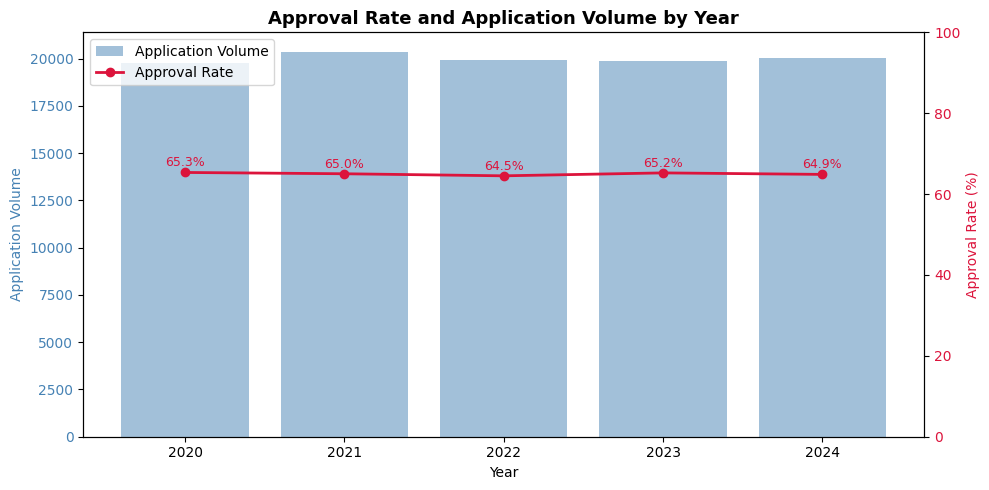

In [27]:
# Compute approval rate and application volume per year
yearly = (
    df.groupby("application_year")["approved_binary"]
    .agg(approval_rate="mean", volume="count")
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for application volume on the primary y-axis
ax1.bar(yearly["application_year"], yearly["volume"], color="steelblue", alpha=0.5, label="Application Volume")
ax1.set_xlabel("Year")
ax1.set_ylabel("Application Volume", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(yearly["application_year"])

# Line chart for approval rate on the secondary y-axis
# Dual axis lets us compare trend direction without volume swamping the rate
ax2 = ax1.twinx()
ax2.plot(yearly["application_year"], yearly["approval_rate"] * 100, color="crimson", marker="o", linewidth=2, label="Approval Rate")
ax2.set_ylabel("Approval Rate (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 100)

# Annotate each point with its approval rate value
for _, row in yearly.iterrows():
    ax2.text(row["application_year"], row["approval_rate"] * 100 + 1.5, f"{row['approval_rate'] * 100:.1f}%", ha="center", fontsize=9, color="crimson")

# Combine legends from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Approval Rate and Application Volume by Year", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Since data is synthethetic, there won't be any macroeconimical factors to consider when designing the model

In [ ]:
# Numerical columns grouped by thematic section from the data dictionary
section_columns = {
    "Section 1: Applicant Demographics": [
        "age", "dependents_count", "years_employed",
        "zip_code_prefix", "years_at_current_address"
    ],
    "Section 2: Income & Financial Profile": [
        "annual_income", "monthly_income", "other_annual_income", "total_household_income",
        "monthly_rent_mortgage", "monthly_car_payment", "monthly_utilities", "monthly_insurance",
        "monthly_food_expense", "monthly_entertainment_expense", "monthly_subscriptions",
        "total_monthly_expenses", "savings_account_balance", "checking_account_balance",
        "investment_portfolio_balance", "retirement_account_balance",
        "total_assets", "total_liabilities", "net_worth", "debt_to_income_ratio"
    ],
    "Section 3: Credit Bureau Profile": [
        "fico_score", "equifax_score", "experian_score", "transunion_score", "avg_bureau_score",
        "credit_history_length_months", "num_total_credit_accounts", "num_open_accounts",
        "num_closed_accounts", "num_credit_cards", "num_retail_store_cards", "num_auto_loans",
        "num_mortgage_accounts", "num_student_loans", "num_personal_loans",
        "total_revolving_credit_limit", "total_revolving_balance_used", "credit_utilization_ratio",
        "hard_inquiries_last_6mo", "hard_inquiries_last_12mo", "hard_inquiries_last_24mo",
        "late_payments_last_12mo", "late_payments_last_24mo", "derogatory_marks_count",
        "collections_accounts", "bankruptcy_count", "foreclosure_count", "repossession_count",
        "oldest_account_age_months", "newest_account_age_months"
    ],
    "Section 4: Banking Relationship": [
        "bank_relationship_years", "checking_account_age_months", "savings_account_age_months",
        "avg_monthly_deposits", "avg_monthly_withdrawals", "nsf_incidents_last_12mo",
        "overdraft_incidents_last_12mo", "payroll_direct_deposit_amount",
        "existing_cc_balance", "existing_cc_credit_limit"
    ],
    "Section 5: Application Details": [
        "application_year", "application_month", "application_hour",
        "requested_credit_limit", "authorized_user_count", "self_reported_monthly_rent"
    ],
    "Section 6: Risk & Fraud Indicators": [
        "fraud_risk_score", "identity_verification_score", "address_stability_score",
        "stated_vs_verified_income_ratio", "application_velocity_score",
        "synthetic_identity_score", "predicted_default_probability", "loss_given_default_estimate"
    ],
    "Section 7: Bureau Tradeline Details": [
        "revolving_balance", "revolving_credit_limit", "revolving_utilization_rate",
        "total_installment_balance", "monthly_installment_payment",
        "open_revolving_accounts", "open_installment_accounts",
        "mortgage_outstanding_balance", "auto_loan_outstanding_balance",
        "student_loan_outstanding_balance", "personal_loan_outstanding_balance",
        "max_delinquency_days_ever", "max_delinquency_days_24mo",
        "months_since_last_delinquency", "months_since_last_inquiry",
        "months_since_last_derogatory", "public_records_count",
        "tax_liens_count", "civil_judgments_count"
    ],
    "Section 8: Behavioral & Lifestyle": [
        "active_subscription_count", "monthly_restaurant_spend", "monthly_gas_spend",
        "monthly_grocery_spend", "monthly_healthcare_spend", "monthly_entertainment_spend",
        "monthly_home_improvement_spend", "estimated_annual_card_spend", "autopay_setup_likelihood"
    ],
    "Section 9: Economic Context": [
        "fed_funds_rate_at_application", "state_unemployment_rate", "state_median_household_income",
        "cost_of_living_index", "housing_price_index", "cpi_inflation_rate", "regional_credit_stress_index"
    ],
    "Section 10: Engineered & Model Features": [
        "income_to_requested_limit_ratio", "employment_stability_score", "payment_behavior_score",
        "inquiry_burden_score", "account_type_mix_score", "derogatory_severity_score",
        "income_stability_score", "bureau_score_variance", "affordability_index",
        "credit_capacity_ratio", "monthly_disposable_income", "disposable_income_ratio",
        "financial_health_score", "underwriting_model_score_v1", "underwriting_model_score_v2",
        "underwriting_model_score_v3", "combined_risk_score"
    ],
    "Section 11: Supplemental Contact & Channel": [
        "banking_product_count", "avg_transaction_amount", "num_transactions_last_30d",
        "largest_single_purchase_ever", "months_since_last_cc_application",
        "application_completion_time_mins", "income_growth_rate_yoy", "num_address_changes_5yr"
    ]
}

for section_name, cols in section_columns.items():

    # Keep only columns that are present in the dataframe and are numeric
    valid_cols = [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

    # Skip sections with fewer than 2 numeric columns — no correlations to show
    if len(valid_cols) < 2:
        print(f"Skipping {section_name} — fewer than 2 numeric columns")
        continue

    corr = df[valid_cols].corr()

    # Mask the upper triangle to avoid duplicate pairs
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Scale figure height to the number of columns so labels never overlap
    size = max(8, len(valid_cols))
    fig, ax = plt.subplots(figsize=(size, size * 0.8))

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4,
        linecolor="white",
        square=True,
        ax=ax
    )

    ax.set_title(f"Correlation Heatmap — {section_name}", fontsize=13, fontweight="bold", pad=14)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

    plt.tight_layout()
    plt.show()

# 7. Section 4: Approval Decision Logic Validation

In [31]:
"""
Test whether the hard rules and score-based conditions in the data dictionary
actually produce the expected outcomes in the dataset
"""

# ── Hard Rule 1: FICO Score < 480 → Automatic Decline ───────────────────────
fico_decline = df[df['fico_score'] < 480]
fico_decline_rate = (fico_decline['target_approved'] == 'No').mean() * 100
fico_any_approved = (fico_decline['target_approved'] == 'Yes').sum()

print("\n--- Hard Rule 1: FICO Score < 480 → Automatic Decline ---")
print(f"  Applicants with FICO < 480:      {len(fico_decline):,}")
print(f"  Decline rate:                    {fico_decline_rate:.2f}%")
print(f"  Approvals (should be 0):         {fico_any_approved:,}")
print(f"  Rule holds: {'YES ✅' if fico_any_approved == 0 else 'NO ❌ — rule violated'}")

# ── Hard Rule 2: Bankruptcy Count > 1 → Automatic Decline ───────────────────
bk_decline = df[df['bankruptcy_count'] > 1]
bk_decline_rate = (bk_decline['target_approved'] == 'No').mean() * 100
bk_any_approved = (bk_decline['target_approved'] == 'Yes').sum()

print("\n--- Hard Rule 2: Bankruptcy Count > 1 → Automatic Decline ---")
print(f"  Applicants with bankruptcy > 1:  {len(bk_decline):,}")
print(f"  Decline rate:                    {bk_decline_rate:.2f}%")
print(f"  Approvals (should be 0):         {bk_any_approved:,}")
print(f"  Rule holds: {'YES ✅' if bk_any_approved == 0 else 'NO ❌ — rule violated'}")

# ── Hard Rule 3: Debt-to-Income > 85% → Automatic Decline ───────────────────
# DTI is stored as a ratio (e.g. 0.85 = 85%)
dti_decline = df[df['debt_to_income_ratio'] > 0.85]
dti_decline_rate = (dti_decline['target_approved'] == 'No').mean() * 100
dti_any_approved = (dti_decline['target_approved'] == 'Yes').sum()

print("\n--- Hard Rule 3: Debt-to-Income > 85% → Automatic Decline ---")
print(f"  Applicants with DTI > 85%:       {len(dti_decline):,}")
print(f"  Decline rate:                    {dti_decline_rate:.2f}%")
print(f"  Approvals (should be 0):         {dti_any_approved:,}")
print(f"  Rule holds: {'YES ✅' if dti_any_approved == 0 else 'NO ❌ — rule violated'}")

# ── Score-based: Combined Risk Score bands ───────────────────────────────────
print("\n--- Score-Based Rules: Combined Risk Score → Approval Probability ---")

score_bands = {
    '>= 700 (Higher)':    df['combined_risk_score'] >= 700,
    '650–699 (Moderate)': (df['combined_risk_score'] >= 650) & (df['combined_risk_score'] < 700),
    '600–649 (Lower)':    (df['combined_risk_score'] >= 600) & (df['combined_risk_score'] < 650),
    '< 600 (Very Low)':   df['combined_risk_score'] < 600,
}

prev_rate = None
monotonic = True

for label, mask in score_bands.items():
    group = df[mask]
    rate = (group['target_approved'] == 'Yes').mean() * 100
    direction = ''
    if prev_rate is not None:
        direction = '↓' if rate < prev_rate else '↑ ❌ (expected decrease)'
        if rate >= prev_rate:
            monotonic = False
    prev_rate = rate
    print(f"  {label:<26} n={len(group):>6,}  approval rate={rate:>6.2f}%  {direction}")

print(f"\n  Approval rate decreases with score band: {'YES ✅' if monotonic else 'NO ❌'}")

# ── Soft Signal 1: financial_health_score positive → higher approval ─────────
print("\n--- Soft Signal 1: Positive financial_health_score → Higher Approval ---")

# Split at median to compare low vs high health score groups
median_fhs = df['financial_health_score'].median()
low_fhs  = df[df['financial_health_score'] <= median_fhs]
high_fhs = df[df['financial_health_score'] >  median_fhs]
low_rate  = (low_fhs['target_approved']  == 'Yes').mean() * 100
high_rate = (high_fhs['target_approved'] == 'Yes').mean() * 100

print(f"  Median financial_health_score:   {median_fhs:.4f}")
print(f"  Approval rate (score <= median): {low_rate:.2f}%")
print(f"  Approval rate (score >  median): {high_rate:.2f}%")
print(f"  Higher score → higher approval:  {'YES ✅' if high_rate > low_rate else 'NO ❌'}")

# ── Soft Signal 2: Prior default + FICO < 620 → Penalised (lower approval) ──
print("\n--- Soft Signal 2: Prior Default + FICO < 620 → Penalised Score ---")

compound_mask   = (df['prior_default_flag'] == 'Yes') & (df['fico_score'] < 620)
no_compound_mask = ~compound_mask

compound_rate    = (df[compound_mask]['target_approved']    == 'Yes').mean() * 100
no_compound_rate = (df[no_compound_mask]['target_approved'] == 'Yes').mean() * 100

print(f"  Applicants meeting compound rule: {compound_mask.sum():,}")
print(f"  Approval rate (compound rule):    {compound_rate:.2f}%")
print(f"  Approval rate (all others):       {no_compound_rate:.2f}%")
print(f"  Compound rule penalises approval: {'YES ✅' if compound_rate < no_compound_rate else 'NO ❌'}")

print("\n" + "=" * 70)



--- Hard Rule 1: FICO Score < 480 → Automatic Decline ---
  Applicants with FICO < 480:      21,583
  Decline rate:                    91.22%
  Approvals (should be 0):         1,896
  Rule holds: NO ❌ — rule violated

--- Hard Rule 2: Bankruptcy Count > 1 → Automatic Decline ---
  Applicants with bankruptcy > 1:  1,027
  Decline rate:                    39.73%
  Approvals (should be 0):         619
  Rule holds: NO ❌ — rule violated

--- Hard Rule 3: Debt-to-Income > 85% → Automatic Decline ---
  Applicants with DTI > 85%:       55,504
  Decline rate:                    61.93%
  Approvals (should be 0):         21,132
  Rule holds: NO ❌ — rule violated

--- Score-Based Rules: Combined Risk Score → Approval Probability ---
  >= 700 (Higher)            n=     0  approval rate=   nan%  
  650–699 (Moderate)         n=     0  approval rate=   nan%  ↑ ❌ (expected decrease)
  600–649 (Lower)            n=     0  approval rate=   nan%  ↑ ❌ (expected decrease)
  < 600 (Very Low)           n=

Since the dataset shows cut-off conditions fail to meet their corresponding condition, the model will be trained without these rows so that cut-off conditions and outcomes are met when predicting approval and credit limit or implement simple logic within the model.